In [243]:
import numpy as np
import pandas as pd

np.random.seed(42)

N = 100000

x = np.random.uniform(0.1, 10, N)


y_true = (
    5 * x * np.exp(2)
    - np.log(x)
)


gaussian = np.random.normal(0, 12, N)

heavy = np.random.standard_t(df=2, size=N) * 6

hetero = np.random.normal(0, x * 2)

spikes = np.zeros(N)
mask = np.random.rand(N) < 0.03
spikes[mask] = np.random.uniform(-100, 100, mask.sum())

y = y_true + gaussian + heavy + hetero + spikes

df = pd.DataFrame({
    "x": x,
    "y": y
})

df.to_csv("function_dataset.csv", index=False)

print(df.head())

          x           y
0  3.807947  192.820093
1  9.512072  370.970859
2  7.346740  270.796786
3  6.026719  196.491996
4  1.644585   68.527746


In [244]:
df.shape

(100000, 2)

In [245]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,r2_score
import pandas as pd
import matplotlib.pyplot as plt


In [246]:
data_sets = pd.read_csv("function_dataset.csv")
X = data_sets["x"].to_frame()
y = data_sets["y"].to_frame()

In [247]:
X,y

(              x
 0      3.807947
 1      9.512072
 2      7.346740
 3      6.026719
 4      1.644585
 ...         ...
 99995  7.943818
 99996  7.814604
 99997  6.777089
 99998  5.044528
 99999  3.960094
 
 [100000 rows x 1 columns],
                 y
 0      192.820093
 1      370.970859
 2      270.796786
 3      196.491996
 4       68.527746
 ...           ...
 99995  284.186549
 99996  280.052263
 99997  273.819285
 99998  209.090587
 99999  164.311020
 
 [100000 rows x 1 columns])

In [248]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [249]:
X_train,y_train

(              x
 75220  1.515767
 48955  4.148120
 44966  4.850403
 13568  9.537223
 92727  2.175228
 ...         ...
 6265   5.058678
 54886  6.015111
 76820  0.642575
 860    7.777723
 15795  2.183576
 
 [80000 rows x 1 columns],
                 y
 75220   94.056092
 48955  154.695749
 44966  192.201419
 13568  333.891083
 92727   69.436037
 ...           ...
 6265   146.940938
 54886  247.516298
 76820   39.385027
 860    312.791688
 15795   80.924011
 
 [80000 rows x 1 columns])

In [250]:
model = RandomForestRegressor()

model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor()

In [251]:
pred = model.predict(X_test)

In [252]:
accuracy = r2_score(y_test,pred)

In [253]:
accuracy

0.9086214762067986

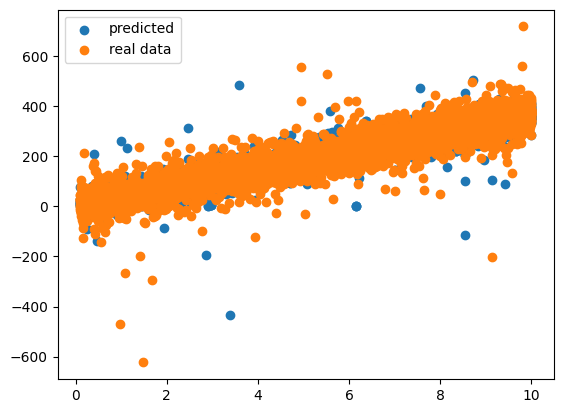

In [254]:
plt.scatter(X_test,pred,label="predicted")
plt.scatter(X_test,y_test,label="real data")

plt.legend()
plt.show()

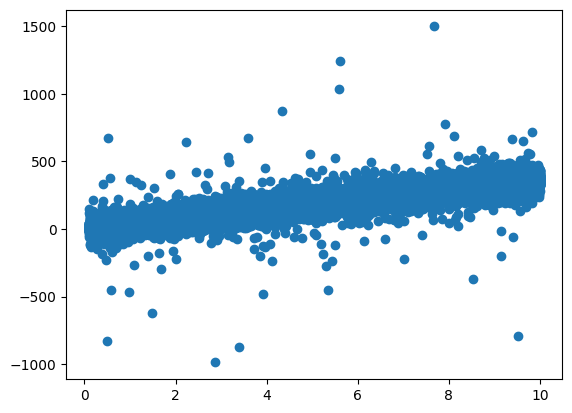

In [255]:
plt.scatter(X,y)
plt.show()

# model using pytorch

In [256]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader , TensorDataset
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

In [257]:
data_sets = pd.read_csv("function_dataset.csv")
X = data_sets["x"].to_frame()
y = data_sets["y"].to_frame()
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [258]:
X_train = torch.from_numpy(X_train.to_numpy()).float()
X_test = torch.from_numpy(X_test.to_numpy()).float()

y_train = torch.from_numpy(y_train.to_numpy()).float()
y_test = torch.from_numpy(y_test.to_numpy()).float()

In [259]:
class FunctionModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

  def forward(self, x):
      return self.net(x)

In [260]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [261]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FunctionModel().to(device)


train_dataset = TensorDataset(X_train , y_train)

train_loader = DataLoader(train_dataset , batch_size=32 , shuffle=True)

In [262]:
criterion = nn.MSELoss().to(device)
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [263]:
epoches = 50

for epoch in range(epoches):

    model.train()

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        predictions = model(X_batch)

        loss = criterion(predictions, y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}/{epoches}  Loss: {loss.item():.4f}")

Epoch 1/50  Loss: 602.4118
Epoch 2/50  Loss: 318.8420
Epoch 3/50  Loss: 366.7619
Epoch 4/50  Loss: 2169.9983
Epoch 5/50  Loss: 1151.3887
Epoch 6/50  Loss: 472.8831
Epoch 7/50  Loss: 386.4429
Epoch 8/50  Loss: 497.3417
Epoch 9/50  Loss: 3609.8877
Epoch 10/50  Loss: 473.1295
Epoch 11/50  Loss: 742.9242
Epoch 12/50  Loss: 272.3640
Epoch 13/50  Loss: 696.6223
Epoch 14/50  Loss: 330.6293
Epoch 15/50  Loss: 395.4543
Epoch 16/50  Loss: 311.3544
Epoch 17/50  Loss: 394.9767
Epoch 18/50  Loss: 439.3231
Epoch 19/50  Loss: 440.7847
Epoch 20/50  Loss: 299.0204
Epoch 21/50  Loss: 916.7047
Epoch 22/50  Loss: 825.6875
Epoch 23/50  Loss: 552.3422
Epoch 24/50  Loss: 412.9508
Epoch 25/50  Loss: 381.1324
Epoch 26/50  Loss: 1138.2742
Epoch 27/50  Loss: 400.8443
Epoch 28/50  Loss: 495.1875
Epoch 29/50  Loss: 525.9726
Epoch 30/50  Loss: 577.3507
Epoch 31/50  Loss: 802.9087
Epoch 32/50  Loss: 665.9150
Epoch 33/50  Loss: 443.4498
Epoch 34/50  Loss: 763.6976
Epoch 35/50  Loss: 293.4807
Epoch 36/50  Loss: 553.54

In [264]:
model.eval()
with torch.no_grad():
    predictions = model(X_test.to(device)).cpu().numpy()

y_true = y_test.cpu().numpy()

print("R² :", r2_score(y_true, predictions))

R² : 0.9395781755447388


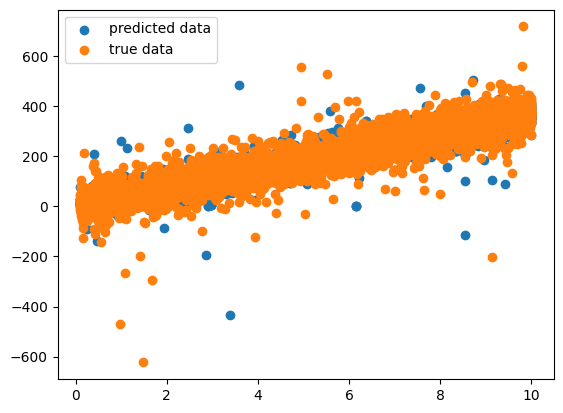

In [269]:
plt.scatter(X_test,pred,label="predicted data")
plt.scatter(X_test,y_test,label="true data")

plt.legend()
plt.show()